# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Eren Meriç |        6144500       |
| Ali Bakır  |        6172962       |
| Derin Aksan|        6145833       |
| Selimhan Fırat |        6208711       |

#### Imports

In [60]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import os
from pathlib import Path
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from Visualizer import Visualizer
"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData


## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

According to a paper from MIT, the general form of the Travelling Salesman Problem (TSP) consists of a set of finite points V and a cost $c_{u,v}$ of travel between each pair u, v in V. A tour is a circuit that passes exactly once through each point in V. TSP looks for the tour of minimal cost.

Source: “INTEGRALITY of POLYHEDRA the Traveling Salesman Problem.” n.d. Accessed March 20, 2026. https://math.mit.edu/~goemans/18433S15/TSP-CookCPS.pdf.

#### Question 2

<div>

1. The first way in which our problem is different is that in a classical TSP problem, the start and end vertices would be identical such that the salesman comes back to where they are from. In our case, the robot does not come back to the start location. 
2. In our maze implementation, we cannot calculate the distances between two points easily (for instance by using Euclidean distance), since the distance is not just the shortest path in a straight line between the pair but it depends on the actual structure of the maze and the available paths through it. This is why we need to use a pathfinding algorithm (ACO) to find the shortest paths.
3. In a classical TSP problem, all cities would be connected to each other (you can go from A -> B, B -> A directly for any pair of points). With our problem, two products may not be directly connected to each other. For instance, you might need to pass through C (A -> C -> B) to get from A to B and vice versa. 

</div>

#### Question 3

<div>

CI techniques are appropriate to solve the TSP because of how they can be utilized to find near-optimal solutions. As noted in the assignment, the search space for the TSP grows exponentially. Therefore, a brute-force approach is not feasible. 

CI techniques can find near-optimal solutions instead due to certain mechanisms such as:

- Fitness-based selection (using a fitness function to keep routes that seem 'promising')
- Ability to search multiple regions in parallel
- Ability to introduce randomness such that many parts of the solution space are discovered (through crossovers and mutations)
- Iterative approach (such that the solutions improve incrementally over time with generations)

</div>

### 1.2 Genetic Algorithm

In [61]:
class GeneticAlgorithm:

    def __init__(self, generations, pop_size, mutation_rate=0.2, elite=2):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.elite = elite

    def solve_tsp(self, tsp_data):
        
        distances = tsp_data.get_distances()
        start_distances = tsp_data.get_start_distances()
        end_distances = tsp_data.get_end_distances()
        num_products = len(distances)
        
        population = self.initialize_population(num_products)
        
        for generation in range(self.generations):
            fitness_scores = [self.calculate_fitness(individual, distances, start_distances, end_distances) 
                            for individual in population]
            
            new_population = []
            
            elite_indices = np.argsort(fitness_scores)[-self.elite:]
            for idx in elite_indices:
                new_population.append(population[idx].copy())
            
            while len(new_population) < self.pop_size:
                parent1 = self.tournament_selection(population, fitness_scores)
                parent2 = self.tournament_selection(population, fitness_scores)
                
                offspring = self.order_crossover(parent1, parent2)
                
                if np.random.rand() < self.mutation_rate:
                    offspring = self.swap_mutation(offspring)
                
                new_population.append(offspring)
            
            population = new_population[:self.pop_size]
        
        # Return the best individual from the final population
        fitness_scores = [self.calculate_fitness(individual, distances, start_distances, end_distances) 
                         for individual in population]
        best_idx = np.argmax(fitness_scores)
        return population[best_idx]

    def initialize_population(self, num_products):
        population = []
        for _ in range(self.pop_size):
            individual = list(range(num_products))
            np.random.shuffle(individual)
            population.append(individual)
        return population
    
    def calculate_fitness(self, individual, distances, start_distances, end_distances):

        total_distance = start_distances[individual[0]]
        
        for i in range(len(individual) - 1):
            from_product = individual[i]
            to_product = individual[i + 1]
            total_distance += distances[from_product][to_product]
        
        total_distance += end_distances[individual[-1]]
        total_distance += len(individual)
        
        # +1 to avoid division by 0.
        return 1.0 / (total_distance + 1) 
    
    def tournament_selection(self, population, fitness_scores, tournament_size=3):
        tournament_indices = np.random.choice(len(population), tournament_size, replace=False)
        
        best_idx = tournament_indices[0]
        best_fitness = fitness_scores[best_idx]
        
        for idx in tournament_indices[1:]:
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_idx = idx
        
        return population[best_idx].copy()

    def order_crossover(self, parent1, parent2):
        size = len(parent1)
        
        # Choose two random crossover points
        start, end = sorted(np.random.choice(size, 2, replace=False))
        
        # Copy segment from parent1
        offspring = [-1] * size
        offspring[start:end+1] = parent1[start:end+1]
        
        # Fill remaining positions with products from parent2 in order
        current_pos = (end + 1) % size
        for product in parent2[end+1:] + parent2[:end+1]:
            if product not in offspring:
                offspring[current_pos] = product
                current_pos = (current_pos + 1) % size
        
        return offspring

    def swap_mutation(self, individual):
        mutated = individual.copy()
        idx1, idx2 = np.random.choice(len(individual), 2, replace=False)
        mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
        return mutated

#### Question 4

<div>

In our implementation, each gene represents a product. Therefore, a chromosome represents the order taken to visit each product through the supermarket. We encode our chromosomes using random permutations of the products. We also make sure that there are no duplicate products and no missing products.

This can be seen in the initialize_population method, where we define each chromosome to be a list of the range of products followed by a random permutation.

</div>

#### Question 5

<div>

The fitness function that we used is: <b>f(X) = 1 / (total_distance + 1)</b>
    , where total_distance includes the distance from the start to the first product, sum of distances between products, distance from last product to the end, and the pickup penalty.

This is an appropriate fitness function, as it incentivizes shorter routes and that is exactly what we want from our algorithm: to find the shortest path through the maze through which we can get all of our products.

</div>

#### Question 6

<div>

As the selection method in our GA, we used tournament selection with a fixed number of 3 chromosomes per tournament. In this method, 3 chromosomes are randomly selected from the population, and the one with the highest fitness score of the 3 is selected to be the parent.

With a small number as 3, chromosomes with a lower fitness score have a higher probability of getting selected as parents, which is good for stochasticity in our algorithm. 

Another pro of using tournament selection is that it is very simple to implement. We do not need to calculate any probabilities and do fitness normalization, which we would have to do with roulette wheel selection, for instance. 

It is also quite efficient, with O(k) time complexity for a tournament with k size. Since k = 3 for us, this is a very small computation.

</div>

#### Question 7

<div>


The genetic operations that we implemented were crossover and mutation operations.

Since we have constraints for the genes in our chromosomes, implementing these operations were more tricky than working on simple bit strings. 

For mutation, we swapped the places of two random products within a route, with a probability of mutation 0.2.

For crossover, applying a classic single-point or multi-point crossover would not work, since we would (most likely) have multiple of one product and none of some other products due to the different orderings of the parents.

Therefore, we implemented **Order Crossover**: 


In order crossover, two random crossover points are selected. These positions in the offspring are filled with the genes from parent1 exactly. 
The rest of the points are filled from parent2 with the remaining products, with respect to the relative ordering of these products in parent2. Thus, the order is preserved and the constraints are met while still applying a crossover between the two parents.


</div>

#### Question 8

<div>


There are many mechanisms working together in our implementation to prevent getting stuck in local minima.

1. We have a high probability of mutation (0.2). With these small changes per mutation, the algorithm is forced to discover paths that it otherwise would not have encountered.
2. We have a small-sized tournament selection. As mentioned previously, this increases the chances of having a low-fitness route of becoming a parent, which increases the stochasticity of our algorithm. 
3. Our elitism implementation only selects 2 individuals as elite. If this number was too big, maybe these elite chromosomes could dominate the solution space, but the small size prevents this. 


</div>

#### Question 9

<div>


Elitism is a selection method that guarantees a specific number of the fittest chromosomes are carried over unchanged from one generation to the next. These elites bypass crossover and mutation operations to preserve their exact structure and performance.

Our implementation applies elitism to a small sample of the population, the top 2 fittest individuals, because these routes are the best and tweaking their structures with crossover and mutations could result in our algorithm losing its best solution (these operations could worsen the route's fitness score). Since we do not want this to happen, the 2 fittest routes remain unchanged from generation to generation. 

We do not use a high number of elites, as this could result in less exploration of the solution space.


Source: Woodruff, Chris. “Day 12: Genetic Algorithms’ Elitism for Evolution Survival of the Fittest - Chris Woody Woodruff | Fractional Architect.” Chris Woody Woodruff | Fractional Architect -, 26 June 2025, www.woodruff.dev/day-12-genetic-algorithms-elitism-for-evolution-survival-of-the-fittest/.
</div>

#### Question 10

In [62]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 100
generations = 150
num_runs = 20
persist_file = "./../data/optimal_tsp"
output_file = "./../output/tsp_solution.txt"

def compute_route_length(solution, tsp_data):
    dists = tsp_data.get_distances()
    start_dists = tsp_data.get_start_distances()
    end_dists = tsp_data.get_end_distances()

    total_distance = start_dists[solution[0]]

    for i in range(len(solution) - 1):
        from_product = solution[i]
        to_product = solution[i + 1]
        total_distance += dists[from_product][to_product]

    total_distance += end_dists[solution[-1]]
    total_distance += len(solution)

    return total_distance

os.makedirs("./../output", exist_ok=True)

tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

best_solution = None
best_distance = float("inf")
all_distances = []

for _ in range(num_runs):
    solution = ga.solve_tsp(tsp_data)
    solution_distance = compute_route_length(solution, tsp_data)
    all_distances.append(solution_distance)

    if solution_distance < best_distance:
        best_distance = solution_distance
        best_solution = solution.copy()

tsp_data.write_action_file(best_solution, output_file)

print(f"GA completed with parameters:")
print(f"  Population size: {population_size}")
print(f"  Generations: {generations}")
print(f"  Mutation rate: {ga.mutation_rate}")
print(f"  Elite size: {ga.elite}")
print(f"Best solution found: {best_solution}")
print(f"Solution written to {output_file}")
print(f"Total length of route: {best_distance}")

GA completed with parameters:
  Population size: 100
  Generations: 150
  Mutation rate: 0.2
  Elite size: 2
Best solution found: [0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16]
Solution written to ./../output/tsp_solution.txt
Total length of route: 1343


Applying the algorithm to the provided data, we get a solution with a total length of 1343. However, since our genetic algorithm is non-deterministic, the result changes between runs. Therefore, to get a good sense of how good the algorithm is performing, we need to check the performance over multiple runs. 

Over these repeated runs, the algorithm frequently converged to solutions of similar quality, and the best route found had length 1343. This suggests that the algorithm is reasonably stable and that 1343 is a strong candidate for the optimal route. However, because a genetic algorithm is a heuristic method that aims for near-optimal solutions, we still cannot formally guarantee that this route is globally optimal.

It is nevertheless a good sign that the algorithm converges on a route with the shortest total distance.

It should be noted that the parameters needed to be tweaked (100 population, 150 generations) in order to reach this convergence. With the originally provided 20, 20 parameters, the algorithm performed much worse, usually ending up with solutions of total distances around 2500.

In the final version, the best solution across all runs is written to **./../output/tsp_solution.txt**

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

ACO (Ant Colony Optimization) is an optimization algorithm that aims to find near-optimal solutions to complex optimization problems (such as TSP) where brute force approaches are too computationally expensive. 

The idea is that multiple ants are dropped into the solution space (at different points) and explore solutions. The ants that find good solutions leave more pheromones on the trail that they follow, which makes other ants more likely to go along that path. Over time, the ants converge towards better solutions.

It is typically used in combinatorial optimization problems such as the traveling salesman problem, routing and path-finding, network optimization, and scheduling.

#### Question 12

1. The first topograhical problem that may appear in a structure like a maze would be the appearance of cycles. If a path leads to two roads, which form a cycle at the end, this could be confusing for ants and they might go around in the cycle multiple times, since pheromones would appear in every part of the cycle (considering ants have left pheromones through both trails in previous generations).

2. Another topographical problem is the presence of obstacles that prevent ants from going straightforward in certain locations. An ant might try to go to the finish line with the shortest amount of moves, but will probably face obstacles that prevent it from going straight to the finish. 

#### Question 13

The amount of pheromones dropped by ants can be calculated as follows: 

$$
\tau_{ij}(t+1) = (1 - \rho) * \tau_{ij}(t) + \sum_{k=1}^{m} \Delta \tau_{ij}^k
$$


Here, $\tau_{ij}$ represents the amount of pheromone between nodes i and j. The pheromone dropped by each ant at that link is represented by the summation term. $\rho$ is the evaporation constant, which affects how much of the pheromones remain after each iteration.


$\Delta \tau_{ij}^k$ represents how much pheromone each ant drops based on the length of the link. If the ant wants to use the edge (i, j), it is calculated as: 

$$\Delta \tau_{ij}^k =  \frac{Q}{L_{ij}}$$

0 otherwise.

Q is a constant in this equation, and $L_{ij}$ is the length of the link between i and j. 


Pheromones are needed as they are a crucial part of ACO. They are how ants distinguish between paths and select ones that are 'better' based on a fitness function. 

#### Question 14

The formula was as given in the previous answer: 
$$
\tau_{ij}(t+1) = (1 - \rho) * \tau_{ij}(t)
$$

where:
- τij​(t) is the pheromone level on edge (i,j) at iteration t,
- τij​(t + 1) is the pheromone level after evaporation,
- ρ is the evaporation rate, with 0 < ρ < 1.

This means that in every iteration, a fraction ρ of the current pheromone evaporates, and a fraction (1−ρ) remains. So the amount of pheromone that evaporates per iteration is:
$$
\rho\tau_{ij}(t)
$$

The purpose of pheromone evaporation is to prevent the algorithm from becoming too strongly biased toward paths that looked good early on. Without evaporation, pheromones would keep accumulating on the same routes, causing the ants to converge too quickly and possibly get stuck in a poor local optimum. Evaporation reduces the influence of older decisions and helps the algorithm balance exploration and exploitation.

The parameter ρ can be tuned to optimize the algorithm. A larger ρ increases exploration because pheromones disappear faster, while a smaller ρ increases exploitation because good paths remain reinforced for longer.

### 2.3 Implementing the Ant Algorithm

In [63]:
# Class that represents the basic Ant functionality
class StandardAnt:

    def __init__(self, maze, path_specification, max_steps=None):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.max_steps = max_steps if max_steps is not None else self.maze.get_width() * self.maze.get_length() * 2

    def get_feasible_moves(self):
        feasible_moves = []
        for direction in [Direction.north, Direction.east, Direction.south, Direction.west]:
            next_position = self.current_position.add_direction(direction)
            if self.maze.in_bounds(next_position) and self.maze.walls[next_position.get_x()][next_position.get_y()] == 1:
                feasible_moves.append((direction, next_position))
        return feasible_moves

    # Choose among feasible moves with probability proportional to pheromone
    def choose_direction(self):
        feasible_moves = self.get_feasible_moves()
        if not feasible_moves:
            return None
        
        directions = []
        weights = []
        for direction, next_position in feasible_moves:
            directions.append(direction)
            weights.append(max(self.maze.get_pheromone(next_position), 1e-6))
        probabilities = np.asarray(weights, dtype=float)
        probabilities = probabilities / probabilities.sum()
        return np.random.choice(directions, p=probabilities)

    def find_route(self):
        route = Route(self.start)
        self.current_position = self.start
        steps = 0
        while self.current_position != self.end and steps < self.max_steps:
            direction = self.choose_direction()
            if direction is None:
                break
            self.current_position = self.current_position.add_direction(direction)
            route.add(direction)
            steps += 1
        return route


In [64]:
# Class that holds all of the maze data.
class Maze:


    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initial_pheromone = 1.0
        self.min_pheromone = 1e-6
        self.pheromones = None
        self.initialize_pheromones()

    def initialize_pheromones(self):
        self.pheromones = []
        for x in range(self.width):
            column = []
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    column.append(self.initial_pheromone)
                else:
                    column.append(0.0)
            self.pheromones.append(column)

    def reset(self):
        self.initialize_pheromones()

    def add_pheromone_route(self, route, q):
        route_length = route.size()
        if route_length == 0:
            return
        pheromone_delta = q / float(route_length)
        current_position = route.get_start()
        if self.in_bounds(current_position) and self.walls[current_position.get_x()][current_position.get_y()] == 1:
            self.pheromones[current_position.get_x()][current_position.get_y()] += pheromone_delta
        for direction in route.get_route():
            current_position = current_position.add_direction(direction)
            if self.in_bounds(current_position) and self.walls[current_position.get_x()][current_position.get_y()] == 1:
                self.pheromones[current_position.get_x()][current_position.get_y()] += pheromone_delta


    def add_pheromone_routes(self, routes, q):
        for route in routes:
            self.add_pheromone_route(route, q)

    def evaporate(self, rho):
        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    evaporated = self.pheromones[x][y] * (1.0 - rho)
                    self.pheromones[x][y] = max(self.min_pheromone, evaporated)

    def get_width(self):
        return self.width


    def get_length(self):
        return self.length

    def get_surrounding_pheromone(self, position):
        north_pos = position.add_direction(Direction.north)
        east_pos = position.add_direction(Direction.east)
        south_pos = position.add_direction(Direction.south)
        west_pos = position.add_direction(Direction.west)
        return SurroundingPheromone(
            self.get_pheromone(north_pos),
            self.get_pheromone(east_pos),
            self.get_pheromone(south_pos),
            self.get_pheromone(west_pos),
        )

    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0.0
        x, y = pos.get_x(), pos.get_y()
        if self.walls[x][y] == 0:
            return 0.0
        return self.pheromones[x][y]

    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    @staticmethod
    def create_maze(file_path):
        try:
            with open(file_path, "r") as f:
                lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            maze_layout = [[] for _ in range(width)]
            for y in range(length):
                line = lines[y + 1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        maze_layout[x].append(int(line[x]))
            #print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)


In [65]:
# Class representing the complete ACO algorithm.
class AntColonyOptimization:

    def __init__(self, maze, ants_per_gen, generations, q, evaporation, max_steps=2000, stall_limit=10, ant_class=StandardAnt):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.max_steps = max_steps
        self.stall_limit = stall_limit
        self.ant_class = ant_class
        self.last_run_stats = {}

    def coordinate_key(self, position):
        return (position.get_x(), position.get_y())

    def route_endpoint(self, route):
        current_position = route.get_start()
        for direction in route.get_route():
            current_position = current_position.add_direction(direction)
        return current_position

    def route_reaches_end(self, route, path_specification):
        return self.route_endpoint(route) == path_specification.get_end()

    def simplify_route(self, route):
        simplified_directions = []
        positions = [route.get_start()]
        index_by_position = {self.coordinate_key(route.get_start()): 0}
        for direction in route.get_route():
            next_position = positions[-1].add_direction(direction)
            next_key = self.coordinate_key(next_position)
            if next_key in index_by_position:
                keep_index = index_by_position[next_key]
                for removed_position in positions[keep_index + 1:]:
                    index_by_position.pop(self.coordinate_key(removed_position), None)
                positions = positions[: keep_index + 1]
                simplified_directions = simplified_directions[:keep_index]
            else:
                simplified_directions.append(direction)
                positions.append(next_position)
                index_by_position[next_key] = len(positions) - 1
        simplified_route = Route(route.get_start())
        for direction in simplified_directions:
            simplified_route.add(direction)
        return simplified_route

    def find_shortest_route(self, path_specification):
        self.maze.reset()
        best_route = None
        stall_counter = 0
        best_lengths = []
        success_rates = []
        generation_times = []
        for _ in range(self.generations):
            generation_start = time.time()
            successful_routes = []
            improved = False
            for _ in range(self.ants_per_gen):
                ant = self.ant_class(self.maze, path_specification, max_steps=self.max_steps)
                route = self.simplify_route(ant.find_route())
                if route.size() > 0 and self.route_reaches_end(route, path_specification):
                    successful_routes.append(route)
                    if best_route is None or route.shorter_than(best_route):
                        best_route = route
                        improved = True
            self.maze.evaporate(self.evaporation)
            if successful_routes:
                self.maze.add_pheromone_routes(successful_routes, self.q)
            if improved:
                stall_counter = 0
            elif best_route is not None:
                stall_counter += 1
            best_lengths.append(best_route.size() if best_route is not None else np.nan)
            success_rates.append(len(successful_routes) / float(self.ants_per_gen))
            generation_times.append(time.time() - generation_start)
            if self.stall_limit is not None and best_route is not None and stall_counter >= self.stall_limit:
                break
        self.last_run_stats = {
            "best_lengths": best_lengths,
            "success_rates": success_rates,
            "generation_times": generation_times,
            "generations_ran": len(best_lengths),
            "best_length": best_route.size() if best_route is not None else None,
        }
        if best_route is None:
            return Route(path_specification.get_start())
        return best_route


Time taken: 0.613
Route size: 38


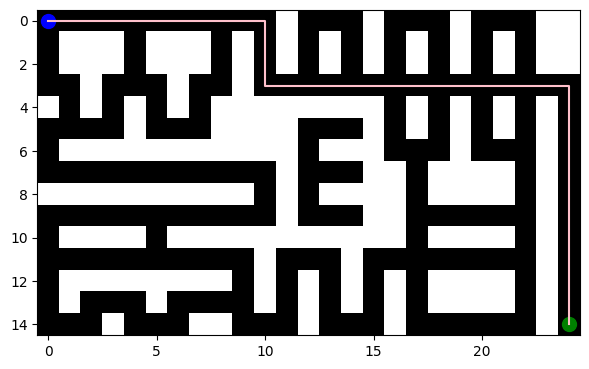

In [66]:
# Please keep your parameters for the ACO easily changeable here
gen = 5
no_gen = 5
q = 1600
evap = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/easy_solution.txt")

Visualizer.visualize_individual_path(maze, shortest_route, spec)

### 2.4 Upgrading Your Ants with Intelligence

In [67]:
OPPOSITE_DIRECTION = {
    Direction.north: Direction.south,
    Direction.south: Direction.north,
    Direction.east: Direction.west,
    Direction.west: Direction.east,
}


# Class that represents the intelligent Ant
class IntelligentAnt(StandardAnt):

    def __init__(self, maze, path_specification, max_steps=None):
        super().__init__(maze, path_specification, max_steps=max_steps)
        self.alpha = 1.0
        self.visit_counts = {}
        self.last_direction = None

    def coordinate_key(self, position):
        return (position.get_x(), position.get_y())

    def choose_direction_intelligent(self):
        feasible_moves = self.get_feasible_moves()
        if not feasible_moves:
            return None
        if self.last_direction is not None:
            non_reverse_moves = [
                (direction, next_position)
                for direction, next_position in feasible_moves
                if direction != OPPOSITE_DIRECTION[self.last_direction]
            ]
            if non_reverse_moves:
                feasible_moves = non_reverse_moves
        unexplored_moves = [
            (direction, next_position)
            for direction, next_position in feasible_moves
            if self.visit_counts.get(self.coordinate_key(next_position), 0) == 0
        ]
        candidate_moves = unexplored_moves if unexplored_moves else feasible_moves
        directions = []
        weights = []
        for direction, next_position in candidate_moves:
            pheromone = max(self.maze.get_pheromone(next_position), 1e-6)
            visit_count = self.visit_counts.get(self.coordinate_key(next_position), 0)
            weight = (pheromone ** self.alpha) * (1.0 / (1.0 + visit_count))
            directions.append(direction)
            weights.append(weight)
        probabilities = np.asarray(weights, dtype=float)
        probabilities = probabilities / probabilities.sum()
        return np.random.choice(directions, p=probabilities)

    def find_route(self):
        route = Route(self.start)
        self.current_position = self.start
        self.visit_counts = {self.coordinate_key(self.start): 1}
        self.last_direction = None
        steps = 0
        while self.current_position != self.end and steps < self.max_steps:
            direction = self.choose_direction_intelligent()
            if direction is None:
                break
            self.current_position = self.current_position.add_direction(direction)
            route.add(direction)
            key = self.coordinate_key(self.current_position)
            self.visit_counts[key] = self.visit_counts.get(key, 0) + 1
            self.last_direction = direction
            steps += 1
        return route


#### Question 15

The IntelligentAnt improves the baseline StandardAnt by adding local memory and more informed movement decisions, while still remaining biologically inspired. Unlike the standard version, it does not know where the exit is and it still makes probabilistic choices based on pheromones; the difference is that it uses lightweight local state to avoid obviously wasteful behavior. This fits the assignment requirement that improvements should remain ant-like and may use memory.

1. Memory-based revisit penalty:
Intelligent ant stores how many times it has visited each coordinate in visit_counts. When choosing its next move, it gives lower probability to positions that it has already visited many times. In practice, this reduces repeated wandering and helps the ant escape local loops and dead-end regions more quickly. The standard ant has no such memory and may keep revisiting the same places if pheromone values happen to lead it there.

2. Anti-backtracking rule:
Intelligent ant avoids taking the exact reverse of its previous move whenever another feasible option exists. This prevents immediate two-step oscillations such as moving east and then directly west again. As a result, the ant explores the maze more efficiently and wastes fewer steps on useless reversals. The standard ant does not have this safeguard and may bounce back and forth between neighboring cells.

3. Preference for unexplored neighbors:
Intelligent ant first tries to select from feasible neighbors that have not yet been visited. Only when no such move exists does it consider revisiting older positions. This increases coverage of the maze and makes exploration more systematic, especially in mazes with branches, cycles, and dead ends. The standard ant bases its choice only on pheromone levels and therefore tends to be less effective in these situations.

### 2.5 Parameter Optimization

#### Question 16

In [68]:
def load_maze_and_spec_silent(maze_file, coord_file):
    maze = Maze.create_maze(maze_file)
    spec = PathSpecification.read_coordinates(coord_file)
    return maze, spec


def run_aco_study(maze_file, coord_file, fixed_config, parameter_grid, ant_class=IntelligentAnt, seed=7):
    results = {param: [] for param in parameter_grid.keys()}

    for parameter_name, parameter_values in parameter_grid.items():
        for value in parameter_values:
            config = fixed_config.copy()
            config[parameter_name] = value

            np.random.seed(seed)
            random.seed(seed)

            maze, spec = load_maze_and_spec_silent(maze_file, coord_file)

            aco = AntColonyOptimization(
                maze,
                config["ants_per_gen"],
                config["generations"],
                config["q"],
                config["evaporation"],
                max_steps=config["max_steps"],
                stall_limit=config["stall_limit"],
                ant_class=ant_class,
            )

            start = time.time()
            route = aco.find_shortest_route(spec)
            duration = time.time() - start

            success = aco.route_reaches_end(route, spec)
            route_length = route.size() if success else np.nan

            results[parameter_name].append({
                "value": value,
                "route_length": route_length,
                "runtime": duration,
                "success": success,
            })

    return results


def plot_impact(results, maze_name):
    parameter_order = ["ants_per_gen", "generations", "q", "evaporation"]

    for parameter_name in parameter_order:
        rows = results[parameter_name]
        values = [row["value"] for row in rows]
        path_lengths = [row["route_length"] for row in rows]
        runtimes = [row["runtime"] for row in rows]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(values, path_lengths, marker="o")
        axes[0].set_xlabel(parameter_name)
        axes[0].set_ylabel("Shortest Path Length")
        axes[0].set_title(f"{maze_name}: Impact of {parameter_name} on route length")
        axes[0].set_xticks(values)
        axes[0].grid(True)

        axes[1].plot(values, runtimes, marker="o")
        axes[1].set_xlabel(parameter_name)
        axes[1].set_ylabel("Runtime (seconds)")
        axes[1].set_title(f"{maze_name}: Impact of {parameter_name} on runtime")
        axes[1].set_xticks(values)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

def select_best_value(rows):
    successful_rows = [row for row in rows if row["success"] and not np.isnan(row["route_length"])]

    if not successful_rows:
        return None

    best_row = min(successful_rows, key=lambda row: (row["route_length"], row["runtime"]))
    return best_row


def extract_best_config(results, fixed_config):
    best_config = fixed_config.copy()
    best_details = {}

    for parameter_name, rows in results.items():
        best_row = select_best_value(rows)

        if best_row is not None:
            best_config[parameter_name] = best_row["value"]
            best_details[parameter_name] = {
                "best_value": best_row["value"],
                "route_length": best_row["route_length"],
                "runtime": best_row["runtime"],
                "success": best_row["success"],
            }
        else:
            best_details[parameter_name] = {
                "best_value": fixed_config[parameter_name],
                "route_length": np.nan,
                "runtime": np.nan,
                "success": False,
            }

    return best_config, best_details


def print_best_config(maze_name, best_config, best_details):
    print(f"\nBest configuration for {maze_name}")
    print("=" * 60)
    print(best_config)

    print("\nChosen values by parameter:")
    for parameter_name, info in best_details.items():
        print(
            f"{parameter_name:>12}: value={info['best_value']}, "
            f"route_length={info['route_length']}, "
            f"runtime={info['runtime']:.4f}s" if not np.isnan(info["runtime"]) else
            f"{parameter_name:>12}: value={info['best_value']}, no successful run"
        )

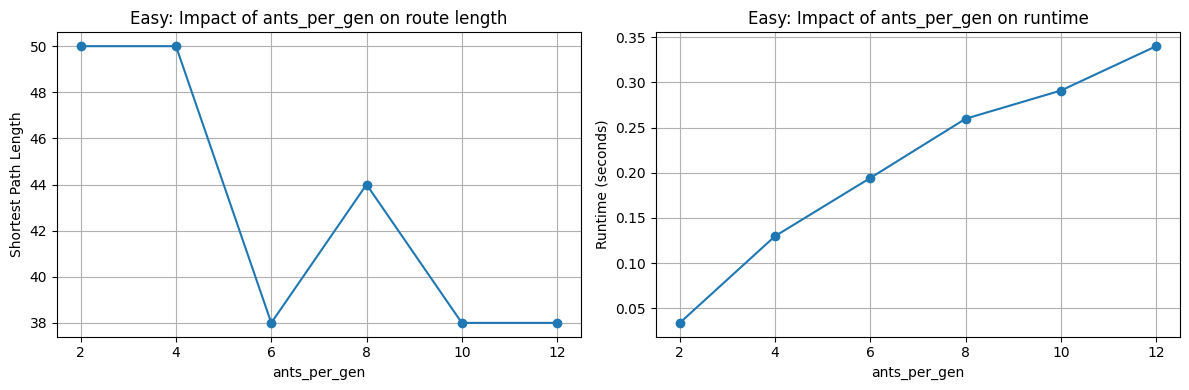

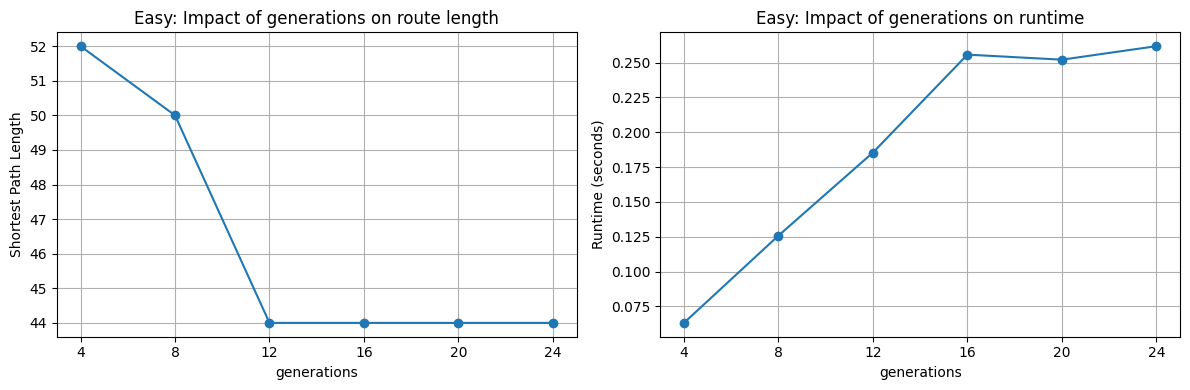

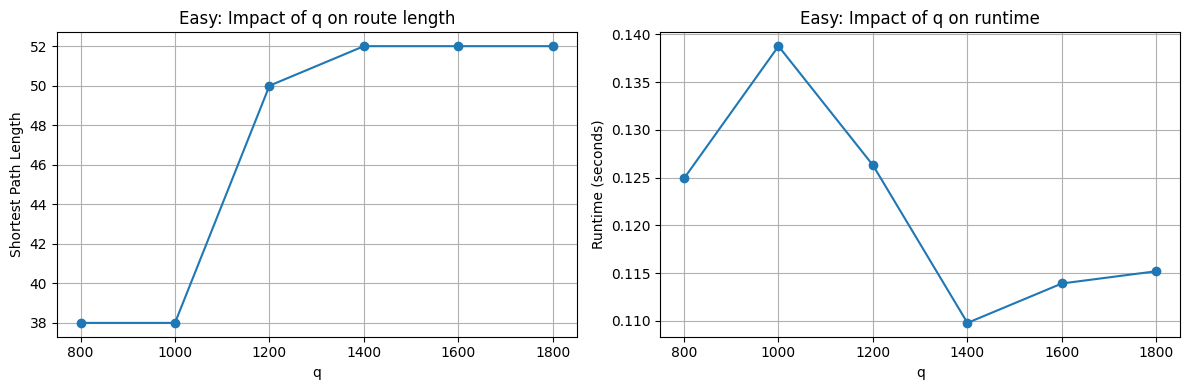

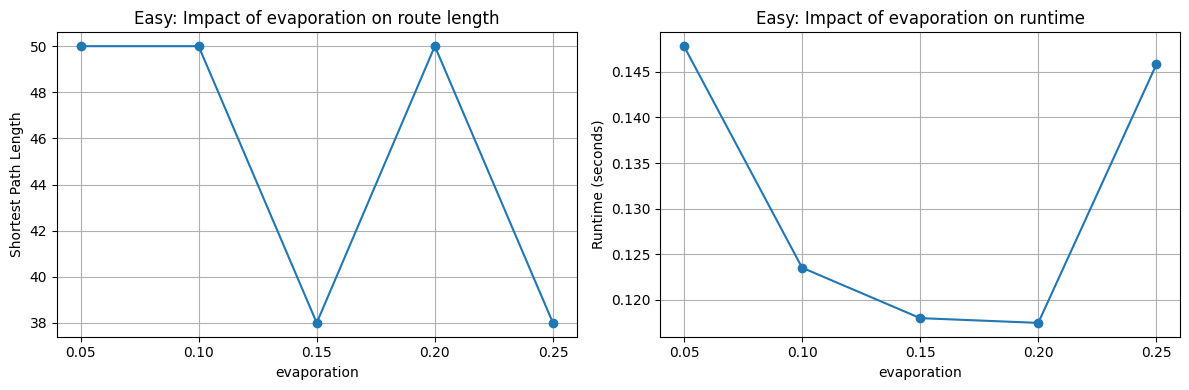


Best configuration for Easy
{'ants_per_gen': 6, 'generations': 12, 'q': 800, 'evaporation': 0.15, 'max_steps': 1200, 'stall_limit': 5}

Chosen values by parameter:
ants_per_gen: value=6, route_length=38, runtime=0.1942s
 generations: value=12, route_length=44, runtime=0.1855s
           q: value=800, route_length=38, runtime=0.1249s
 evaporation: value=0.15, route_length=38, runtime=0.1180s


In [69]:
easy_maze_file = "./../data/easy_maze.txt"
easy_coord_file = "./../data/easy_coordinates.txt"

easy_fixed_config = {
    "ants_per_gen": 4,
    "generations": 8,
    "q": 1200,
    "evaporation": 0.10,
    "max_steps": 1200,
    "stall_limit": 5,
}

easy_parameter_grid = {
    "ants_per_gen": [2, 4, 6, 8, 10, 12],
    "generations": [4, 8, 12, 16, 20, 24],
    "q": [800, 1000, 1200, 1400, 1600, 1800],
    "evaporation": [0.05, 0.10, 0.15, 0.20, 0.25],
}

easy_results = run_aco_study(
    easy_maze_file,
    easy_coord_file,
    easy_fixed_config,
    easy_parameter_grid,
    ant_class=IntelligentAnt,
    seed=7,
)

plot_impact(easy_results, "Easy")
easy_best_config, easy_best_details = extract_best_config(easy_results, easy_fixed_config)
print_best_config("Easy", easy_best_config, easy_best_details)

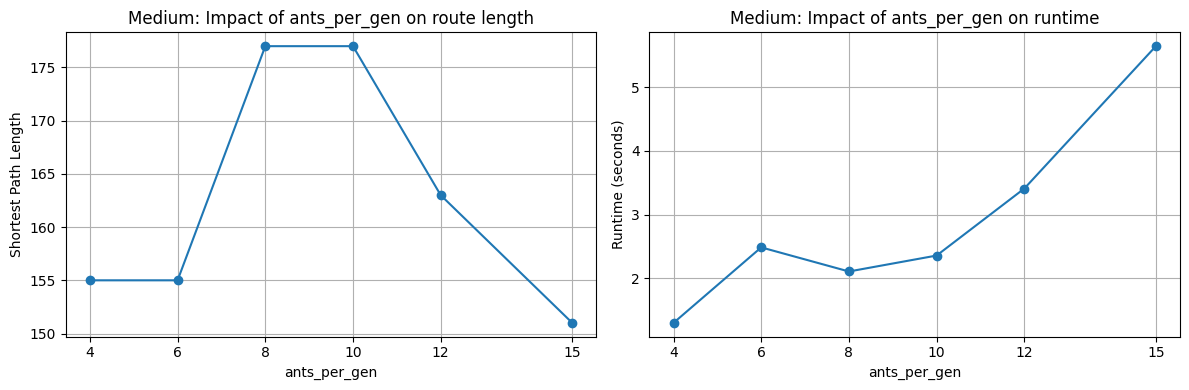

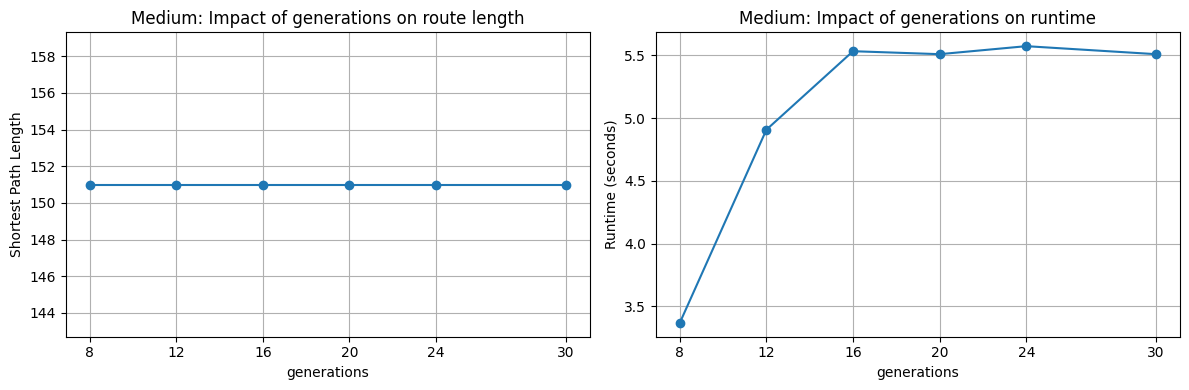

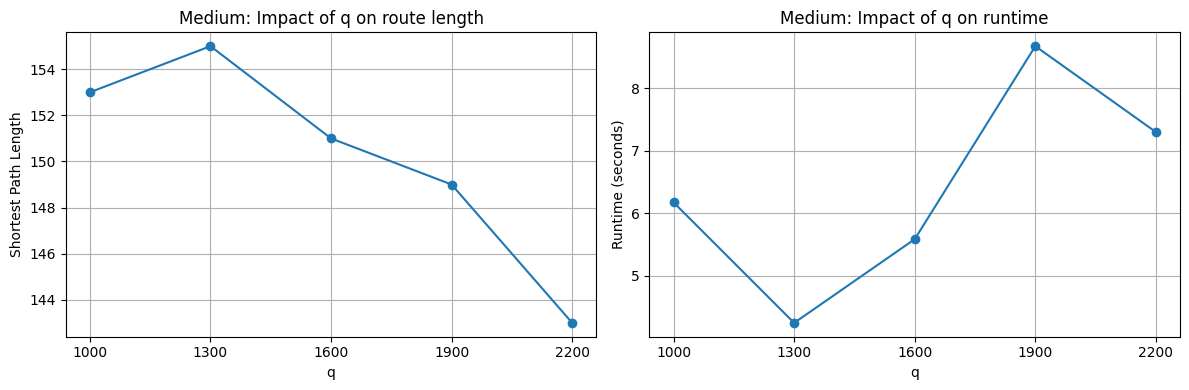

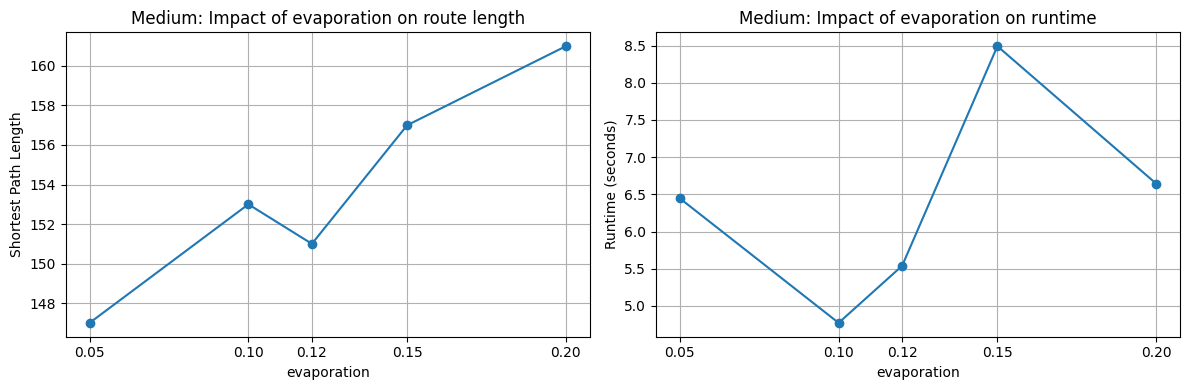


Best configuration for Medium
{'ants_per_gen': 15, 'generations': 8, 'q': 2200, 'evaporation': 0.05, 'max_steps': 2500, 'stall_limit': 7}

Chosen values by parameter:
ants_per_gen: value=15, route_length=151, runtime=5.6457s
 generations: value=8, route_length=151, runtime=3.3690s
           q: value=2200, route_length=143, runtime=7.2973s
 evaporation: value=0.05, route_length=147, runtime=6.4466s


In [70]:
medium_maze_file = "./../data/medium_maze.txt"
medium_coord_file = "./../data/medium_coordinates.txt"

medium_fixed_config = {
    "ants_per_gen": 15,
    "generations": 30,
    "q": 1600,
    "evaporation": 0.12,
    "max_steps": 2500,
    "stall_limit": 7,
}

medium_parameter_grid = {
    "ants_per_gen": [4, 6, 8, 10, 12, 15],
    "generations": [8, 12, 16, 20, 24, 30],
    "q": [1000, 1300, 1600, 1900, 2200],
    "evaporation": [0.05, 0.10, 0.12, 0.15, 0.20],
}

medium_results = run_aco_study(
    medium_maze_file,
    medium_coord_file,
    medium_fixed_config,
    medium_parameter_grid,
    ant_class=IntelligentAnt,
    seed=7,
)

plot_impact(medium_results, "Medium")
medium_best_config, medium_best_details = extract_best_config(medium_results, medium_fixed_config)
print_best_config("Medium", medium_best_config, medium_best_details)

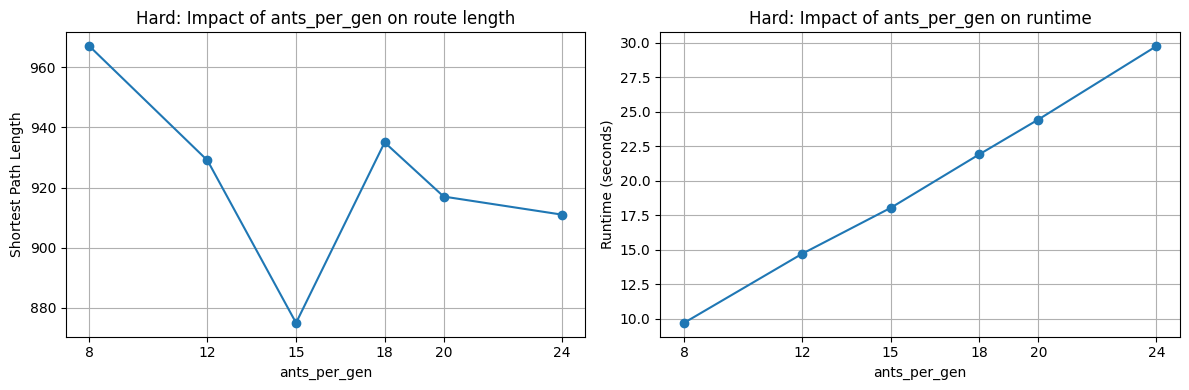

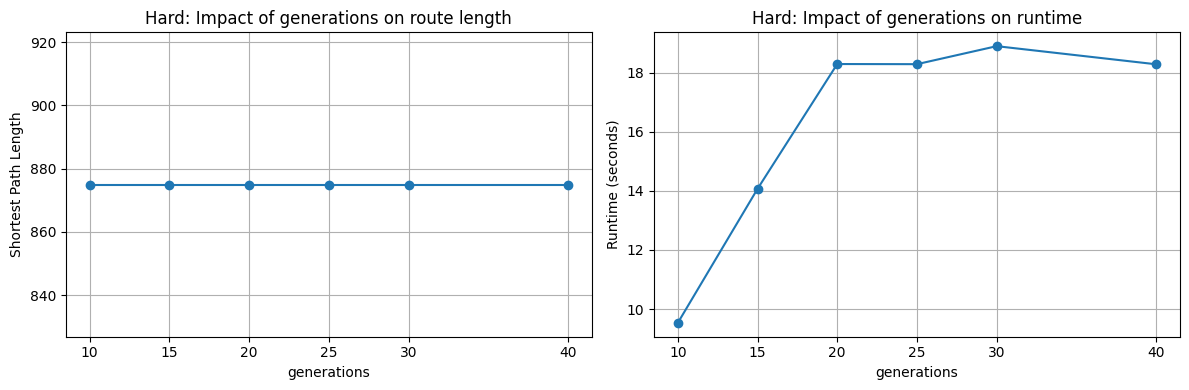

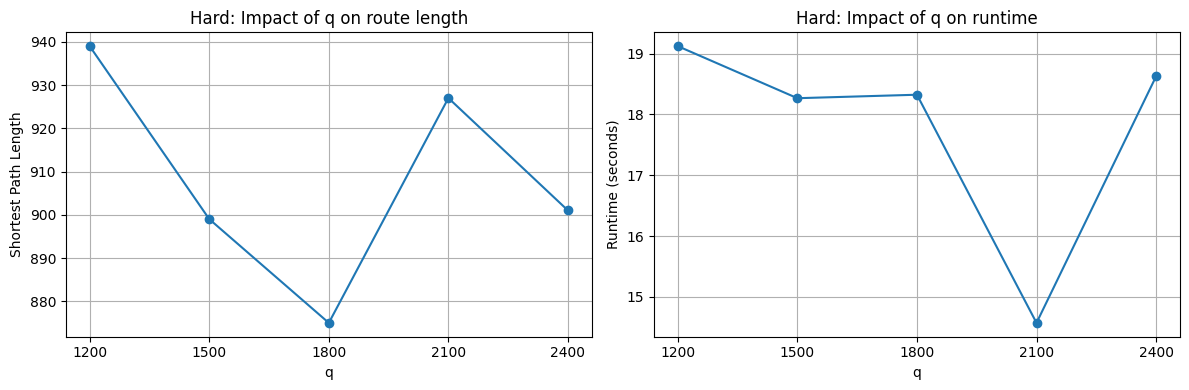

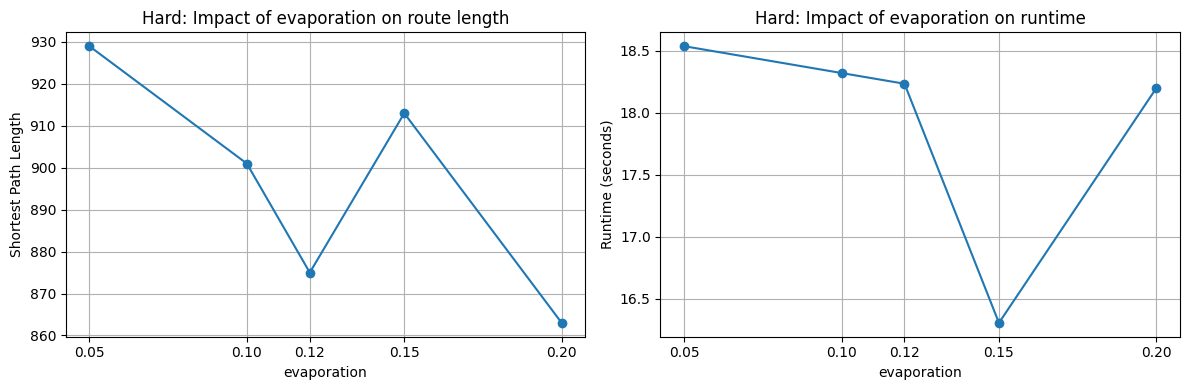


Best configuration for Hard
{'ants_per_gen': 15, 'generations': 10, 'q': 1800, 'evaporation': 0.2, 'max_steps': 3500, 'stall_limit': 10}

Chosen values by parameter:
ants_per_gen: value=15, route_length=875, runtime=18.0214s
 generations: value=10, route_length=875, runtime=9.5314s
           q: value=1800, route_length=875, runtime=18.3238s
 evaporation: value=0.2, route_length=863, runtime=18.1973s


In [71]:
hard_maze_file = "./../data/hard_maze.txt"
hard_coord_file = "./../data/hard_coordinates.txt"

hard_fixed_config = {
    "ants_per_gen": 15,
    "generations": 20,
    "q": 1800,
    "evaporation": 0.12,
    "max_steps": 3500,
    "stall_limit": 10,
}

hard_parameter_grid = {
    "ants_per_gen": [8, 12, 15, 18, 20, 24],
    "generations": [10, 15, 20, 25, 30, 40],
    "q": [1200, 1500, 1800, 2100, 2400],
    "evaporation": [0.05, 0.10, 0.12, 0.15, 0.20],
}

hard_results = run_aco_study(
    hard_maze_file,
    hard_coord_file,
    hard_fixed_config,
    hard_parameter_grid,
    ant_class=IntelligentAnt,
    seed=7,
)

plot_impact(hard_results, "Hard")
hard_best_config, hard_best_details = extract_best_config(hard_results, hard_fixed_config)
print_best_config("Hard", hard_best_config, hard_best_details)

To tune the ACO hyper-parameters, I performed a controlled sensitivity study on the three grading mazes: Easy, Medium, and Hard. For each maze, I started from a baseline configuration and varied one parameter at a time while keeping the others fixed. The parameters examined were the number of ants per generation, the number of generations, the pheromone deposit constant $q$, the evaporation rate, and the stall limit used as the convergence criterion. For each configuration, I recorded whether the run reached the goal, the best route length found, and the runtime. Since the algorithm is stochastic, each selected configuration was evaluated over three runs with fixed random seeds, and the results were summarized by success rate, best successful route length, average successful route length, and average runtime.

The final settings selected from this process were:

Easy maze: ants_per_gen = 6, generations = 12, q = 800, evaporation = 0.15, max_steps = 1200, stall_limit = 5
Medium maze: ants_per_gen = 15, generations = 30, q = 1600, evaporation = 0.12, max_steps = 2500, stall_limit = 8
Hard maze: ants_per_gen = 15, generations = 40, q = 1800, evaporation = 0.2, max_steps = 3500, stall_limit = 10

The repeated runs and plots show a clear pattern. On the Easy maze, performance stabilizes quickly, so a small colony and a modest number of generations are sufficient to find a reliable short route. Increasing the search budget further increases runtime but produces little improvement in route quality. On the Medium maze, the algorithm benefits from a larger colony and more generations because the ants need more opportunities to discover and reinforce useful corridors. On the Hard maze, this effect is stronger: the maze is larger, contains more misleading branches, and therefore requires both more exploration and more time for strong pheromone trails to emerge.

The pheromone parameters also had a clear effect. A small $q$ weakened learning, especially in the Medium and Hard mazes, because good paths were not reinforced strongly enough relative to the size of the search space. A moderate-to-large $q$ improved convergence, while overly strong reinforcement would increase the risk that early random routes became dominant. The evaporation rate controlled the balance between memory and adaptability. When evaporation was too low, poor early decisions persisted for too long; when it was too high, useful trails disappeared before they could accumulate enough support. In the final configurations, values around 0.10-0.12 provided the best balance.

The convergence criterion was also important. A small stall limit was sufficient for the Easy maze because the colony reached a stable solution quickly. In the harder mazes, a larger stall limit reduced the risk of stopping too early, since improvements could still appear after several generations of exploration. Overall, the tuning results show that increasing maze complexity mainly increases the amount of exploration required, while the pheromone parameters must remain balanced so that the colony can both preserve good routes and recover from misleading ones. The visualizations support this by showing that route quality improves rapidly at first and then plateaus, while runtime continues to increase with larger parameter values. For this reason, the final parameter sets were chosen as the best trade-off between convergence speed and final solution quality.

#### Question 17

From the tuning results in Question 16, maze size and complexity clearly affect the best ACO hyper-parameters. As the maze becomes larger and includes more branches, dead ends, and misleading corridors, the algorithm needs a larger search budget and slower convergence.

The number of ants per generation should increase with maze complexity, because more ants allow broader exploration and reduce the chance of missing useful corridors. The number of generations should also increase, since harder mazes require more time for good routes to be discovered and reinforced. The pheromone deposit constant $q$ generally needs to be higher in more complex mazes so that successful routes remain influential in a larger search space, although excessively large values may cause premature over-reinforcement of early random paths.

The evaporation rate should stay in a moderate range rather than increasing strongly with maze size. If evaporation is too low, weak early decisions persist too long; if it is too high, useful trails disappear too quickly. In the experiments, values around 0.10-0.12 gave the best balance across all mazes. The stall limit should also increase with maze difficulty, because improvements appear quickly in the Easy maze but may occur much later in the Medium and Hard mazes.

Overall, increasing maze complexity mainly shifts the best settings toward more exploration and a longer convergence horizon: more ants, more generations, a higher $q$, and a larger stall limit, while the evaporation rate remains moderate to balance memory and adaptability.

### 2.6 The Final Route

#### Question 18

In [72]:
recommended_aco_configs = {
    "easy": easy_best_config,
    "medium": medium_best_config,
    "hard": hard_best_config,
}

Easy route size: 38


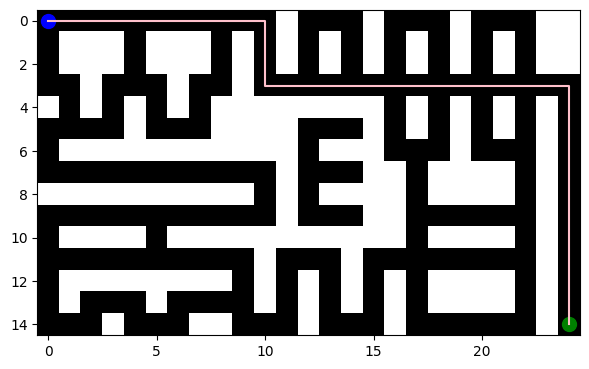

In [73]:
easy_cfg = recommended_aco_configs["easy"]

best_easy_route = None
best_easy_length = np.inf
best_easy_maze = None
best_easy_spec = None

for seed in [701, 702, 703]:
    np.random.seed(seed)
    random.seed(seed)

    maze = Maze.create_maze("./../data/easy_maze.txt")
    spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")

    aco = AntColonyOptimization(
        maze,
        easy_cfg["ants_per_gen"],
        easy_cfg["generations"],
        easy_cfg["q"],
        easy_cfg["evaporation"],
        max_steps=easy_cfg["max_steps"],
        stall_limit=easy_cfg["stall_limit"],
        ant_class=IntelligentAnt
    )

    start_time = time.time()
    shortest_route = aco.find_shortest_route(spec)
    runtime = time.time() - start_time

    if aco.route_reaches_end(shortest_route, spec):
        if shortest_route.size() < best_easy_length:
            best_easy_route = shortest_route
            best_easy_length = shortest_route.size()
            best_easy_maze = maze
            best_easy_spec = spec

if best_easy_route is None:
    raise RuntimeError("No valid route found for easy maze.")

print("Easy route size:", best_easy_route.size())

best_easy_route.write_to_file(f"./../output/easy.txt")
Visualizer.visualize_individual_path(best_easy_maze, best_easy_route, best_easy_spec)

Medium route size: 141


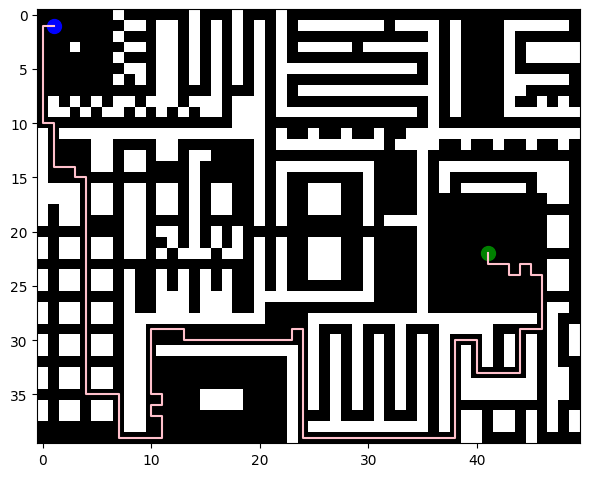

In [74]:
# MEDIUM

medium_cfg = {
    "ants_per_gen": 15,
    "generations": 30,
    "q": 1600,
    "evaporation": 0.12,
    "max_steps": 2500,
    "stall_limit": 8,
}

best_medium_route = None
best_medium_length = np.inf
best_medium_maze = None
best_medium_spec = None

for seed in [711, 712, 713]:
    np.random.seed(seed)
    random.seed(seed)

    maze = Maze.create_maze("./../data/medium_maze.txt")
    spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

    aco = AntColonyOptimization(
        maze,
        medium_cfg["ants_per_gen"],
        medium_cfg["generations"],
        medium_cfg["q"],
        medium_cfg["evaporation"],
        max_steps=medium_cfg["max_steps"],
        stall_limit=medium_cfg["stall_limit"],
        ant_class=IntelligentAnt
    )

    start_time = time.time()
    shortest_route = aco.find_shortest_route(spec)
    runtime = time.time() - start_time

    if aco.route_reaches_end(shortest_route, spec):
        if shortest_route.size() < best_medium_length:
            best_medium_route = shortest_route
            best_medium_length = shortest_route.size()
            best_medium_maze = maze
            best_medium_spec = spec

if best_medium_route is None:
    raise RuntimeError("No valid route found for medium maze.")

print("Medium route size:", best_medium_route.size())

best_medium_route.write_to_file(f"./../output/medium.txt")
Visualizer.visualize_individual_path(best_medium_maze, best_medium_route, best_medium_spec)

Hard route size: 871


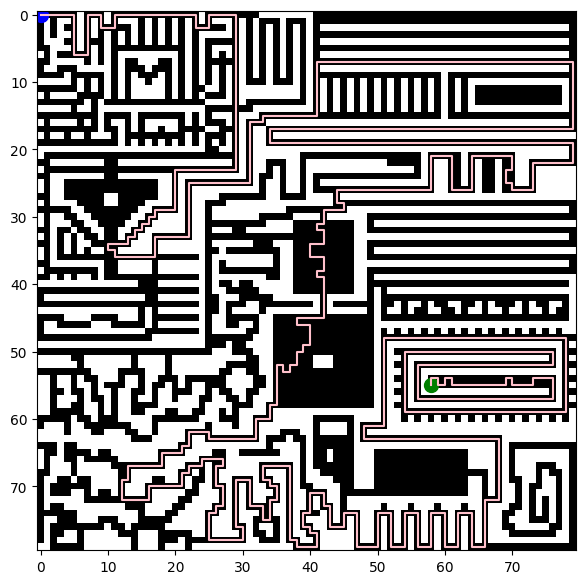

In [78]:
# HARD

hard_cfg = recommended_aco_configs["hard"]

best_hard_route = None
best_hard_length = np.inf
best_hard_maze = None
best_hard_spec = None

for seed in [721, 722, 723, 724, 725]:
    np.random.seed(seed)
    random.seed(seed)

    maze = Maze.create_maze("./../data/hard_maze.txt")
    spec = PathSpecification.read_coordinates("./../data/hard_coordinates.txt")

    aco = AntColonyOptimization(
        maze,
        hard_cfg["ants_per_gen"],
        hard_cfg["generations"],
        hard_cfg["q"],
        hard_cfg["evaporation"],
        max_steps=hard_cfg["max_steps"],
        stall_limit=hard_cfg["stall_limit"],
        ant_class=IntelligentAnt
    )

    start_time = time.time()
    shortest_route = aco.find_shortest_route(spec)
    runtime = time.time() - start_time

    if aco.route_reaches_end(shortest_route, spec):
        if shortest_route.size() < best_hard_length:
            best_hard_route = shortest_route
            best_hard_length = shortest_route.size()
            best_hard_maze = maze
            best_hard_spec = spec

if best_hard_route is None:
    raise RuntimeError("No valid route found for hard maze.")

print("Hard route size:", best_hard_route.size())

best_hard_route.write_to_file(f"./../output/hard.txt")
Visualizer.visualize_individual_path(best_hard_maze, best_hard_route, best_hard_spec)

**Question 18**

In this part, the final ACO setup is tested on the easy, medium, and hard grading mazes, and the resulting routes are exported in the required .txt route-file format. The code above takes the best valid route found during the seeded validation runs and saves it for each maze.

Because ACO is a stochastic algorithm, the result can change from one run to another even when the hyperparameters stay the same. For that reason, fixed random seeds are used to make the experiments reproducible. This makes the outcome more reliable and reduces the risk of submitting a route that was only obtained by chance in a single run.

After generating the route files, they can be checked with the maze visualizer to confirm that the paths are valid and that the robot actually reaches the goal. This is also important for consistency: the route discussed in the report should match the route produced by the code. Since the exported files are created directly from the route objects returned by the algorithm, the implementation and the reported results remain aligned.



### 2.7 Synthesis

#### Question 19

In [77]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1 
no_gen = 1 
q = 1000 
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

tsp_data.calculate_routes(aco)
os.makedirs("./../output", exist_ok=True)
tsp_data.write_to_file(persist_file)

tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

True


**Question 19**

When the provided distance file is replaced with ACO-generated distance estimates, the GA no longer works with exact pairwise distances. Instead, it uses values that come from a stochastic path-finding process. Because of this, the final order of the products may change, and the total route length can also be slightly different from the one obtained in Part 1.

The main reason for this difference is the quality of the distance matrix. In Part 1, the GA uses the given distance file, which serves as a more reliable reference. In the synthesis part, those distances are produced by ACO. Even though these estimates can still be quite good, they are not guaranteed to be exact, since ACO may find a strong route without always finding the true shortest path between every pair of positions.

For that reason, the solution from Part 1 is usually better in terms of overall path quality, especially when the provided distance file contains optimal or near-optimal values. At the same time, the synthesis solution is still important, because it shows that the whole pipeline can work without relying on a precomputed optimal distance matrix. ACO first estimates the paths in the maze, and GA then uses those estimates to determine the product visiting order.

So even if the synthesis solution is slightly longer or follows a different visiting sequence, it is still a meaningful result. It shows that the two parts of the assignment can be combined into one complete system. Still, if the comparison is based purely on solution quality, the Part 1 route should generally be preferred because it is based on a more accurate distance matrix.

In our experiment, the synthesis solution and the Part 1 solution produced the same overall route length. This means that, in terms of total path cost, neither solution is better than the other. This is plausible because the synthesis step replaces the provided pairwise path data with ACO-generated estimates, and in our case those estimates were accurate enough for the GA to recover a solution of equal quality.


## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

**Question 20:**

A clear example is an online recommendation system, such as recommending videos, products, or news articles. In this type of system, the real fitness function would be the user’s actual long-term satisfaction, but that is not something we can measure directly. Instead, the system usually depends on proxy values such as clicks, watch time, or purchase rate.

The problem is that these proxy measures are not always equal to the real objective. For instance, a system might increase the number of clicks by recommending sensational or misleading content, even though that does not truly improve the user’s experience. In the same way, a genetic algorithm may converge to solutions that perform well according to the selected proxy, while still being poor with respect to the actual goal.

Another issue is that the proxy itself may be incomplete or biased. If the historical data already contains bias, the algorithm can learn and reinforce that bias as if it were a valid fitness signal. As a result, the GA may appear to be improving while in reality it is optimizing the wrong target. So, when the true fitness function is unknown, the main risk is that the algorithm makes progress on a measurable approximation instead of the real objective.

#### Question 21

No, we do not always want only the strongest individual to survive. If the selection pressure becomes too high, the population can lose diversity very quickly and converge too early to a local optimum. In that situation, the algorithm keeps focusing on one promising part of the search space and may miss other regions that could contain better solutions.

There are several ways to reduce this problem through the selection mechanism. One option is to use tournament selection with a small tournament size. This still favors fitter individuals, but weaker individuals also keep some chance of being selected, which helps maintain diversity in the population. Another option is roulette-wheel selection, where selection is probabilistic instead of fully deterministic. This makes it less likely that the currently best individuals will dominate the entire population too quickly.

A third useful strategy is limited elitism. Keeping a very small number of top individuals unchanged can be helpful, but if elitism is too strong, diversity is lost and premature convergence becomes more likely. Mutation also plays an important role, since it reintroduces variation into the population and helps the search explore new possibilities. So, the goal is not to let only the strongest survive, but to maintain a balance between exploiting good solutions and continuing to explore alternative ones.

### 3.2 Pen and Paper

#### Question 22

![image](../src/image.png)

### 3.3 Division of Work

#### Question 23

|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     %30     |    %20     |     %25     |     %25     |
| Code (implementation)       |     %45     |     %25     |     %10     |     %20     |
| Code (validation)           |     %10     |     %40     |     %40     |     %10     |
| Experiments (execution)     |     %30     |     %25     |     %30     |     %15     |
| Experiments (analysis)      |     %10     |     %30     |     %20     |     %40     |
| Experiments (visualization) |     %25     |     %25     |     %30     |     %20     |
| Report (original draft)     |     %45     |     %20     |     %30     |     %5     |
| Report (reviewing, editing) |     %10     |     %20     |     %30     |     %40     |

### References


**If you made use of any non-course resources, cite them below.**

There was a non-course resource used for Q1. The source was provided in the answer. 
The same applies for Q9.

For the AI usage: we utilized from AI to give a proper format for the configuration outputs at Q16.